# Iris Flower Classification using Machine Learning

## Project Overview

This project aims to classify Iris flowers into three species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

using machine learning techniques based on flower measurements.

### Objectives
- Load and explore the Iris dataset
- Perform Exploratory Data Analysis (EDA)
- Build a classification model
- Evaluate model performance
- Predict flower species from new measurements

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Jupyter Notebook

# Import Required Libraries

In this section, we import all libraries required for data manipulation,
visualization, machine learning, and model evaluation.

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Dataset

The Iris dataset is loaded from a CSV file stored in the data folder.

In [36]:
df = pd.read_csv("D:\Iris_Flower_Classification_Project\Iris.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [37]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [38]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


# Dataset Overview

Let's examine the dataset dimensions,
column names, and data types.

In [39]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(150, 6)


In [40]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


# Statistical Summary

Generate descriptive statistics for numerical columns.

In [42]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Check Missing Values

Missing values can negatively affect model performance.

In [43]:
#total number of missing values per column
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [44]:
#missing values of individual column
df.isnull()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
145,False,False,False,False,False,False
146,False,False,False,False,False,False
147,False,False,False,False,False,False
148,False,False,False,False,False,False


# Check Duplicate Records

Duplicate records may introduce bias into the model.

In [45]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# Species Distribution

Let's see how many samples belong to each flower species.

In [46]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

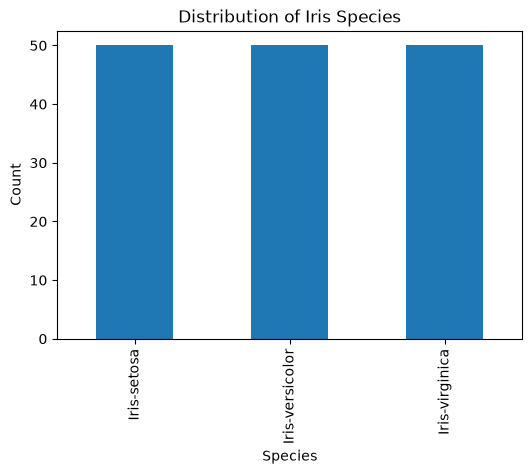

In [47]:
df["Species"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

# Initial Observations

### Findings

- Dataset contains 150 records.
- No missing values found.
- Classes are perfectly balanced.
- Data is clean and ready for exploratory analysis.

The next step is to perform Exploratory Data Analysis (EDA)
and visualize relationships between features.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset by identifying patterns, distributions, relationships between features, and potential outliers.

In this section, we will:
- Visualize the distribution of numerical features.
- Compare feature values across different species.
- Explore relationships between measurements.

# Histograms of Numerical Features

Histograms show how the values of each numerical feature are distributed.

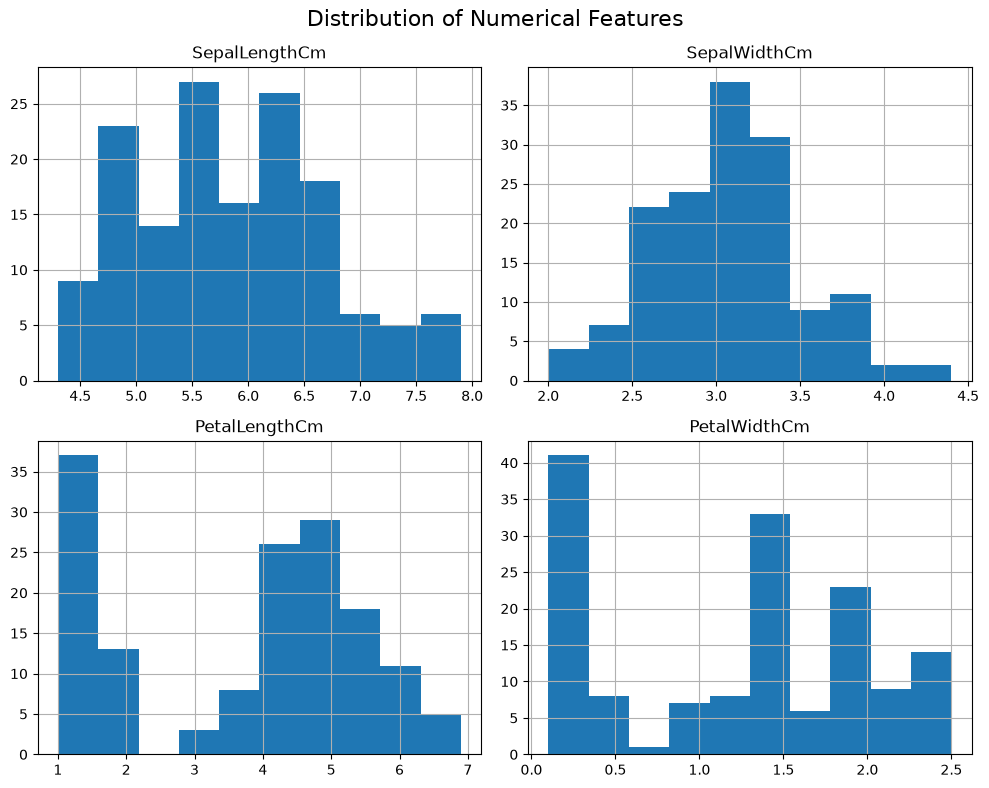

In [48]:
# Select only numerical columns (excluding Id)
numerical_columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

df[numerical_columns].hist(figsize=(10, 8))

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

### Observation

The histograms show that:
- Petal measurements have more distinct distributions.
- Sepal measurements overlap more between species.
- No abnormal distributions are visible.

# Scatter Plot

This plot compares Sepal Length and Petal Length to identify whether different flower species form distinct groups.

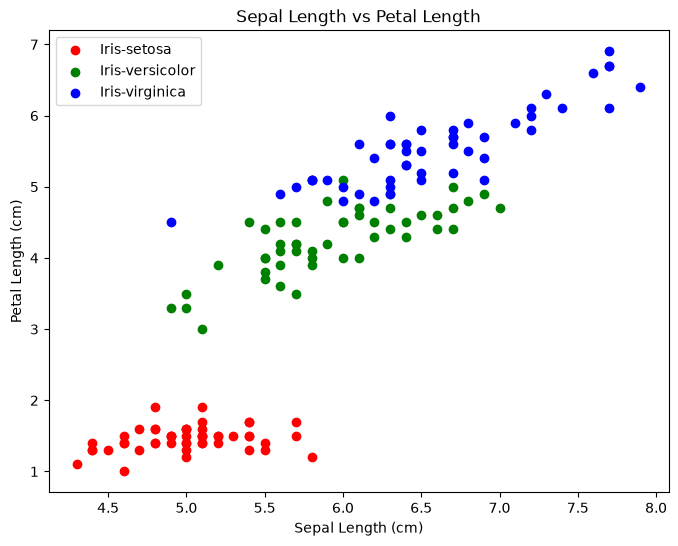

In [49]:
species = df["Species"].unique()

colors = ["red", "green", "blue"]

plt.figure(figsize=(8,6))

for specie, color in zip(species, colors):
    subset = df[df["Species"] == specie]

    plt.scatter(
        subset["SepalLengthCm"],
        subset["PetalLengthCm"],
        label=specie,
        color=color
    )

plt.title("Sepal Length vs Petal Length")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

plt.legend()

plt.show()

### Observation

The scatter plot shows that Iris-setosa is clearly separated from the other two species.

Iris-versicolor and Iris-virginica overlap slightly but still show distinguishable patterns.

# Box Plots

Box plots help identify:
- Median values
- Spread of the data
- Outliers

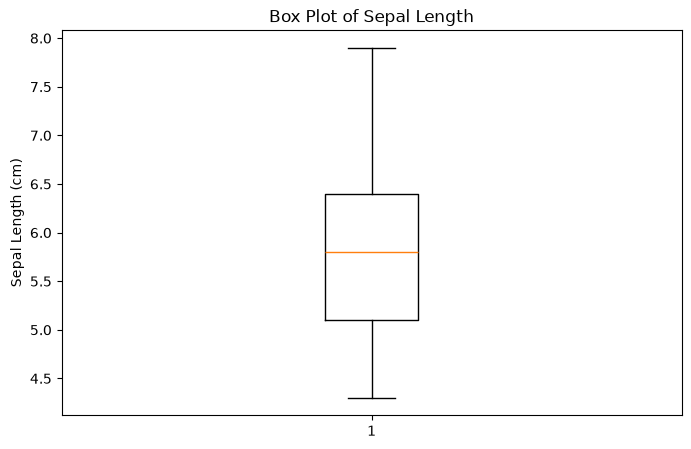

In [50]:
plt.figure(figsize=(8,5))

plt.boxplot(df["SepalLengthCm"])

plt.title("Box Plot of Sepal Length")

plt.ylabel("Sepal Length (cm)")

plt.show()

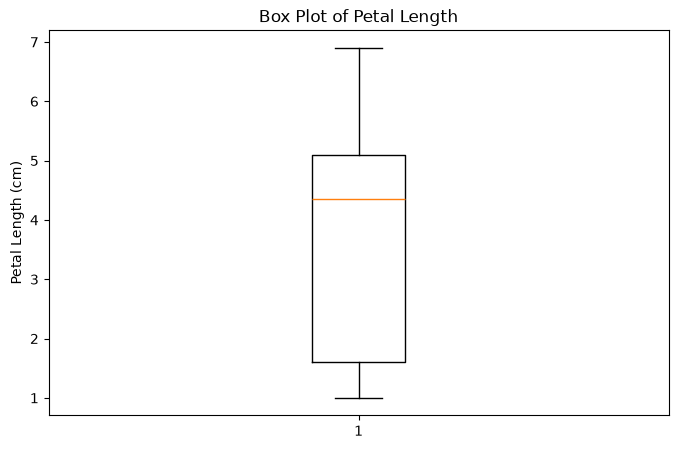

In [51]:
plt.figure(figsize=(8,5))

plt.boxplot(df["PetalLengthCm"])

plt.title("Box Plot of Petal Length")

plt.ylabel("Petal Length (cm)")

plt.show()

### Observation

The box plots indicate:
- Most measurements lie within a reasonable range.
- A few values appear as potential outliers.
- No extreme anomalies are observed.

# Correlation Matrix

Correlation measures the strength of the relationship between numerical features.

Values close to:
- +1 indicate strong positive correlation.
- 0 indicate no correlation.
- -1 indicate strong negative correlation.

In [52]:
correlation = df[numerical_columns].corr()

correlation

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


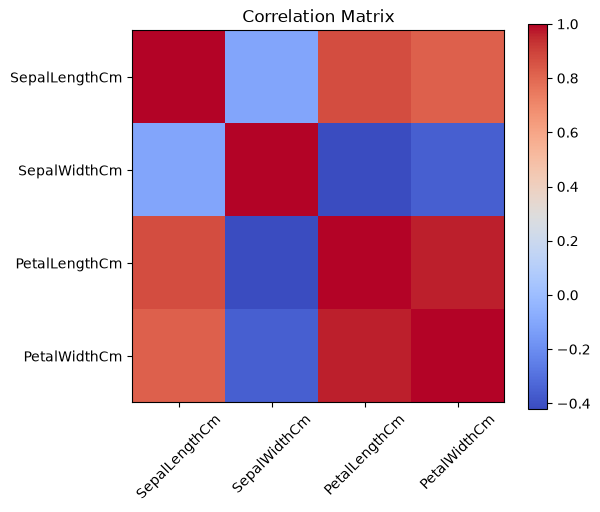

In [53]:
plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation matrix indicates:

- Petal Length and Petal Width have a strong positive correlation.
- Sepal features show weaker relationships.
- Highly correlated features often provide similar information.

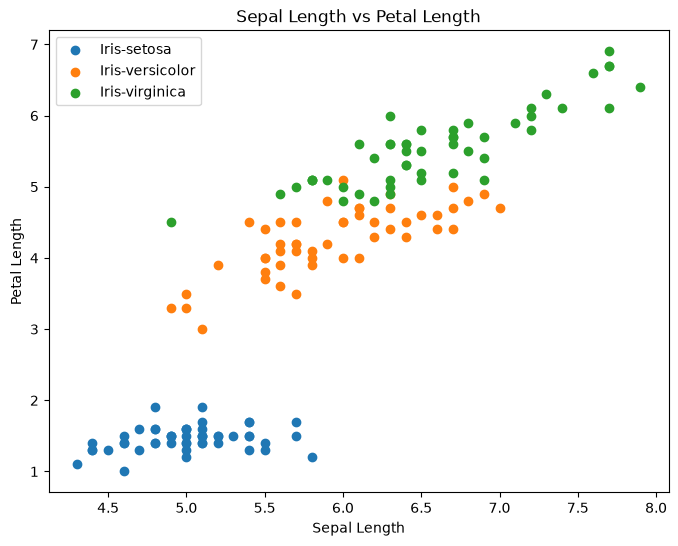

In [54]:
plt.figure(figsize=(8,6))

for specie, color in zip(species, colors):
    subset = df[df["Species"] == specie]

    plt.scatter(
        subset["SepalLengthCm"],
        subset["PetalLengthCm"],
        label=specie
    )

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Sepal Length vs Petal Length")

plt.legend()

plt.savefig("D:\Iris_Flower_Classification_Project\images\scatter_plot.png")

plt.show()

# Summary of Exploratory Data Analysis

Key findings:

- The dataset contains no missing values.
- The classes are balanced.
- Petal measurements provide better separation between species than sepal measurements.
- No significant data quality issues were identified.
- The dataset is suitable for training a classification model.

# Feature Selection

Machine learning models require:
- Features (X): the input variables used for prediction.
- Target (y): the output variable that we want to predict.

For this project:
- Features: Sepal Length, Sepal Width, Petal Length, Petal Width
- Target: Species

In [55]:
# Features (Independent Variables)
X = df.drop(columns=["Id", "Species"])

# Target (Dependent Variable)
y = df["Species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


# Split the Dataset

The dataset is divided into:
- Training set (80%)
- Testing set (20%)

The model learns from the training data and is evaluated using the testing data.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 120
Testing Samples : 30


# Train the Machine Learning Model

We use the Decision Tree Classifier because:
- It is easy to understand.
- It performs well on small datasets.
- It is widely used for classification tasks.

In [57]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Make Predictions

The trained model predicts the species for the test dataset.

In [58]:
y_pred = model.predict(X_test)

y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

# Model Accuracy

Accuracy represents the percentage of correct predictions made by the model.

In [59]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 100.00%


# Confusion Matrix

A confusion matrix compares the actual labels with the predicted labels and helps evaluate model performance.

In [60]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


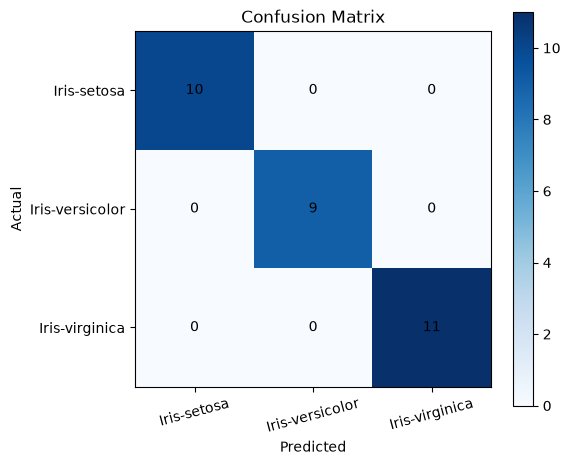

In [61]:
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

classes = sorted(y.unique())

plt.xticks(range(len(classes)), classes, rotation=15)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.tight_layout()

plt.savefig("D:\Iris_Flower_Classification_Project/images/confusion_matrix.png")

plt.show()

# Classification Report

The classification report provides:

- Precision
- Recall
- F1-Score
- Support

These metrics help evaluate the model in more detail.

In [62]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Predict a New Flower

The trained model can classify a flower using new measurements.

In [63]:
sample = pd.DataFrame(
    [[5.1, 2.4, 1.4, 0.2]],
    columns=X.columns
)

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


# Feature Importance

Feature importance indicates how much each feature contributes to the model's predictions.

In [64]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,PetalLengthCm,0.906143
3,PetalWidthCm,0.077186
1,SepalWidthCm,0.016670
0,SepalLengthCm,0.000000


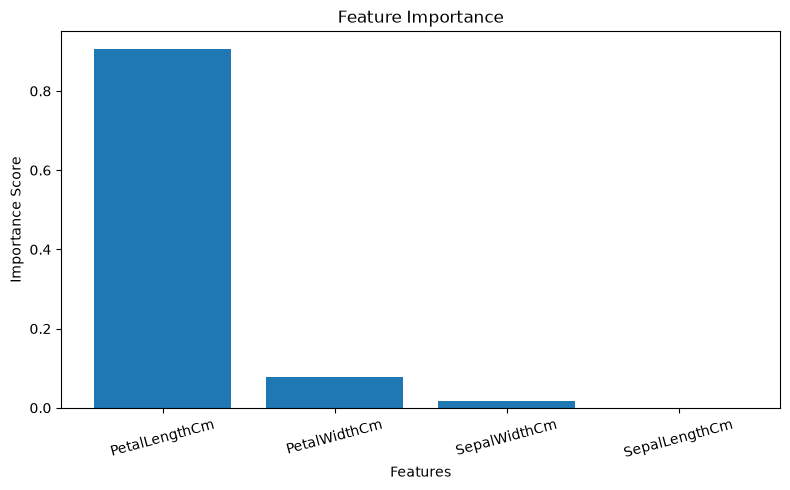

In [66]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("D:\Iris_Flower_Classification_Project\images/feature_importance.png")

plt.show()

# Model Summary

The Decision Tree Classifier successfully classified Iris flowers based on their measurements.

### Results
- The model achieved a high accuracy on the test dataset.
- Petal measurements contributed the most to the classification.
- The confusion matrix indicated that most samples were classified correctly.
- The model demonstrated strong performance for this dataset.